# COE 311k Midterm Project

## Introduction
### The U.S. GDP growth rates, in percentage, from 2010 to 2023 are given by the U.S. Bureau of Economic Analysis (BEA). Three methods of fitting will be applied to the dataset and the most appropriate to future interpolation will be determined through qualitative and quantitative reasoning. The methods analyzed will be natural cubic spline interpolation, polynomial fitting, and least squares linear regression. Each equiped with unique measures of interpreting the data and how outliers, shown by the data given in 2020 quarter two and three, impact their results.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#Defining Data Points
x=[1,5,9,13,17,19,
   22,25,27,28,29,33,
   37,41,42,43,45,
   49,54,56]

#GDP Growth(%)
y=[1.7,0.1,2.3,2.7,1.7,
      5,3,1.5,3.5,1.8,1.3,
      2.5,3.1,-5.1,-28.1,
      33.8,6.3,-1.6,2.4,3.3]

## Cubic Spline Interpolation

In [102]:
#Setting Up Cubic Spline

# Step sizes
h = np.diff(x)

#Setting up the tridiagonal
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x) # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2) # Subdiagonal
    B = np.zeros(n - 2) # Main diagonal
    C = np.zeros(n - 2) # Superdiagonal
    D = np.zeros(n - 2) # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1] # Subdiagonal
        B[i - 1] = 2*(h[i-1]+h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6*((y[i+1]-y[i])/h[i])-((y[i]-y[i-1])/h[i-1]) # Right-hand side vector
    return A, B, C, D

A, B, C, D = setup_tridiagonal_matrix(x, y)



def thomas_algorithm(a, b, c, d):
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x
M = thomas_algorithm(A,B,C,D)

#Ensuring the second derivative at the endpoints is 0
M=np.concatenate(([0],M,[0]))

# Solving for the spline curve
spline=[]
l=len(M)
sx=[]
for i in range(0,l-1):
    for j in np.arange(x[i],x[i+1]+0.1,0.1):
        term1=(M[i]/(6*h[i]))*(x[i+1]-j)**3
        term2=(M[i+1]/(6*h[i]))*(j-x[i])**3
        term3=(y[i]/h[i] - M[i]*h[i]/6)*(x[i+1]-j)
        term4=(y[i+1]/h[i] - M[i+1]*h[i]/6)*(j-x[i])
        sp=term1+term2+term3+term4
        spline.append(sp)
        sx.append(j)


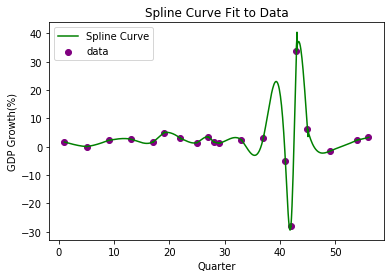

In [103]:
#Graphing the actual points vs. the calculated spline curve
plt.figure()
plt.scatter(x,y,label='data',color='purple')
plt.plot(sx,spline,label='Spline Curve',color='green')
plt.title('Spline Curve Fit to Data')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth(%)')
plt.legend()
plt.show()

### The unknowns being solved for are the second derivatives (M, of which there are 18) for the different spline curves. They are found by first constructing the tridiagonal matrix, which defines the smoothness conditions: the first and second derivatives must be continuous at each of the interior knot points. The thomas algorithm is then used to solve the matrix for the unknown values. To ensure the boundary conditions, the matrix of second derivatives is then concatenated to include a zero as the first and last point. This ensures that the second derivatives at the endpoints equal zero, which is a boundary condition for a natural spline.

### The spline curve is visually smooth across all points as is designed through the smoothness conditions. It passes through every point which is reasonable for most quarters exlcuding the COVID dataset. These points cause an unwanted spike to the curve.

### The method of cubic spline interpolation avoids the Runge phenomenon which is observed in high degree polynomials, causing wild oscillations on the outsides of the data. Exact interpolation is used to pass through every point. While this is useful when the data set encompasses minimal noise (including outliers such as the COVID data), higher degrees can lead to the Runge phenomenon which skews the interpretation of the data, and in turn interpolation potential. Numerical stability is used to weed out the noise. It is best when the data is noisy though it is not ideal if every point in a data set needs to be fit. Weighted least squares would be preferable in this situation as the data is actual rather then experimental. Meaning it is collected rather than calculated using a formula.

## Polynomial vs. Least Squares

In [105]:
#Creating a degree 4 polynomial
#Create Vandermonde matrix for a polynomial of degree 2
degree = 4
V = np.vander(x, N=degree+1, increasing=False)

# V.T * V
VT_V = np.dot(V.T, V)
# V.T * y
VT_y = np.dot(V.T, y)
# Solve for a (coefficients)
coe = np.linalg.solve(VT_V, VT_y)

poly=np.poly1d(coe)
y_poly4=poly(x)


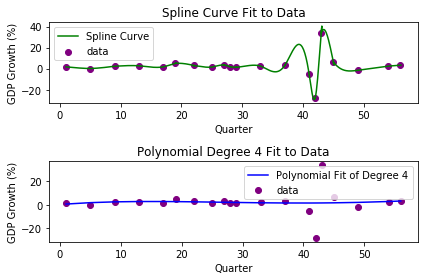

In [106]:
plt.figure()

plt.subplot(2,1,1)
plt.scatter(x,y,label='data',color='purple')
plt.plot(sx,spline,label='Spline Curve',color='green')
plt.title('Spline Curve Fit to Data')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.legend()

plt.subplot(2,1,2)
plt.scatter(x,y,label='data',color='purple')
plt.plot(x,y_poly4,color='blue',label='Polynomial Fit of Degree 4')
plt.title('Polynomial Degree 4 Fit to Data')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.legend()

plt.tight_layout()
plt.show()

### The polynomial fit better and captures the overall trend of the data (smoothing over the COVID points) while the spline curve matches each point exactly. The polynomial fit method works by approximation which is useful when noisy data is included, although it does not pass through all the data points which requires researchers to determine the optimal degree polynomial to help interpret their data best. This can be especially worrysome as problems such as overfitting, underfitting, and the Runge phenomenon appear. Additionally, outliers would change the curve. Spline curves work opposite. They hit every data point, which can be to their advantage. On the other hand, this would also make them susceptible to outliers as instead of working through them they will pass through them.

## Linear Regression

In [107]:
#Data Excluding COVID
x1=np.array(x[:-7])
x2=np.array(x[-3:])
x_new=np.concatenate((x1,x2))

y1=np.array(y[:-7])
y2=np.array(y[-3:])
y_new=np.concatenate((y1,y2))


#Least Squares Linear Model
def leastsq(x,y,n):
    xi=0
    yi=0
    xi2=0
    xiyi=0
    m=0
    c=0
    for i in range(len(x)):
        xi+=x[i]
        yi+=y[i]
        xi2+=(x[i])**2
        xiyi+=x[i]*y[i]
    #Calculate m and c
    m=(n*xiyi-xi*yi)/(n*xi2-(xi**2))
    c=(yi-m*xi)/n
    return m,c

m,c=leastsq(x_new,y_new,len(x_new))
y_calc=m*x_new+c

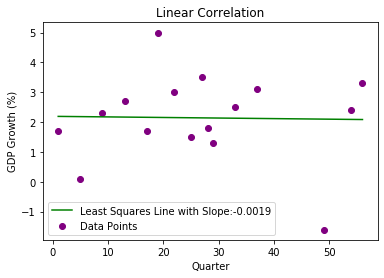

In [108]:
plt.figure()
plt.scatter(x_new,y_new,color='purple',label='Data Points')
plt.plot(x_new,y_calc,color='green',label=f'Least Squares Line with Slope:{m:.2}')
plt.legend()
plt.title('Linear Correlation')
plt.xlabel('Quarter')
plt.ylabel('GDP Growth (%)')
plt.show()

In [109]:
# R-squared value
ss_total = np.sum((y_new - np.mean(y_new))**2)
ss_res = np.sum((y_new - y_calc)**2)
r_squared = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squared:.4f}')

R-squared: 0.0004


### The slope of the line is -0.0019.  The linear trend does not make economic sense for the data as the coefficient of determination is closer to zero than one, with the exclusion of the outlier data, which shows it is not a good fit for explaining the data. It requires the assumption that the data is justifiably linear, the risiduals show a linear pattern, and the data is noisy.

## Method Justification

In [110]:
# MSE Poly Fit
msep = np.mean((y - y_poly4)**2)
print(f'Mean Squared Error for Poly Fit: {msep:.4f}')
# R-squared Poly Fit
ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_poly4)**2)
rp = 1 - (ss_res / ss_total)
print(f'R-squared for Poly Fit: {rp:.4f}')

Mean Squared Error for Poly Fit: 100.6298
R-squared for Poly Fit: 0.0035


### The method I would recomend for interpolation would be cubic spline. Both methods exhibited smoothness within the dataset, however the cubic spline is designed to ensure smoothness within each knot. The polynomial is also at risk for the Runge phenomenon which would make interpolation on the outermost points unreliable. While both methods are sensitive to the outliers as shown by the COVID data, the polynomial method is more susceptible to the impact of outliers in its curve formation. It considers outliers when making its curve rather than just passing through them as does the cubic spline.  On passing through points, the cubic spline passes through all of them, while the polynomial hit a lower amount across the whole dataset. This is represented through the polynomial's high mean squared error.

### Big O notation illustrates the efficiency and scalability of the spline curve and polynomial methods. It does so by interpreting the method's growth rate as a function of its size. The tridiagonal system and the thomas algorithm method for solving the spline curve uses linear time, O(n), while the polynomial method uses cubic time, O(n^3). Linear time shows the algorithm growing linearly with the input size, while cubic time grows proportional to the cubed root of the input size, which is significantly slower. In short, the cubic spline shows a greater efficiency in computational potential.

## Conclusion
### Summarizing, natural cubic spline interpolation was best in showing interpolated data and passed through every point, while polynomial fitting focused more on trend analysis. The cubic spline showed a better fit for the purposes of data interpretation by ensuring smoothness, desregarding the Runge phenomenon, and not allowing outliers to compromise the integrity of the line as compared to the polynomial. While this criteria was useful for the purposes of the data interpretation, polynomial fitting would be more useful for purposes in which trend analysis are favored. Lastly, the linear model did not present as a viable solution as its R squared value showed too low to be considered for the task.
